In [36]:
import importlib
import miaw
import pandas as pd
importlib.reload(miaw)
from miaw import FFNN
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import check_random_state
from sklearn.metrics import accuracy_score


In [37]:
# train-test data
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

random_state = check_random_state(0)
permutation = random_state.permutation(X.shape[0])
X = X[permutation]
y = y[permutation]
X = X.reshape((X.shape[0], -1))

encoder = OneHotEncoder(sparse_output=False, categories='auto')
y_encoded = encoder.fit_transform(y.reshape(-1, 1))

# train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)

(56000, 784) (56000, 10) (14000, 784) (14000, 10)


In [38]:
# Random test sample from Kaggle
test_url = 'https://drive.google.com/uc?id=1VwGTcs1guwJTnUHKdOkMgDUtuW18DbEp'
test_df = pd.read_csv(test_url)

y_test = test_df["label"].values 
X_test = test_df.drop(columns=["label"]).values
print(X_test.shape, y_test.shape)

(10000, 784) (10000,)


# Analysis of Parameters

### 1. Learning Rate

Epoch 1/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 100934.02it/s]


Epoch 1 Completed - Train Loss: 1.5814 - Val Loss: 0.8318


Epoch 2/10: 100%|██████████████████████████████████████████| 56000/56000 [00:00<00:00, 84947.22it/s]


Epoch 2 Completed - Train Loss: 0.6763 - Val Loss: 0.6135


Epoch 3/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 108901.95it/s]


...

Epoch 8 Completed - Train Loss: 0.2821 - Val Loss: 0.3450


Epoch 9/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 107729.80it/s]


Epoch 9 Completed - Train Loss: 0.2627 - Val Loss: 0.3316


Epoch 10/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 95439.20it/s]


Epoch 10 Completed - Train Loss: 0.2470 - Val Loss: 0.3130
Val accuracy: 92.24%, Test accuracy: 93.85%


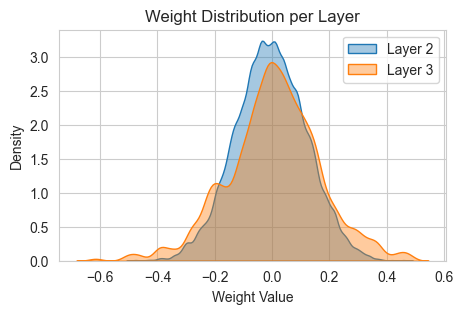

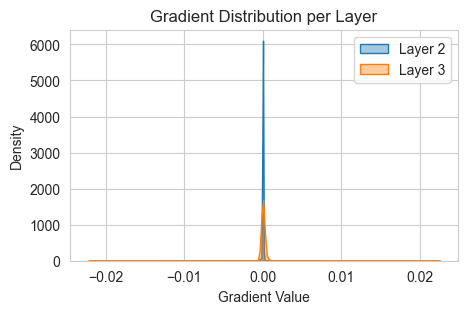

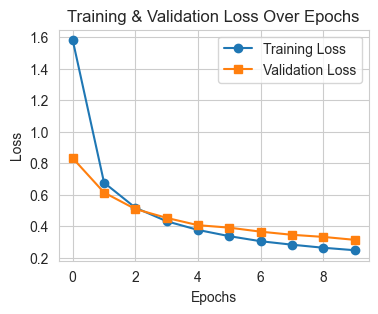

In [39]:
miawlenteraModel = FFNN([784,128,64,10], ['relu','relu','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

history = miawlenteraModel.fit(X_train, y_train, X_val, y_val, epochs=10, batch_size=64, lr=0.05, verbose=1)

lr_val_pred = miawlenteraModel.predict(X_val)
lr_test_pred = miawlenteraModel.predict(X_test)
y_val_labels = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(lr_val_pred, y_val_labels)
test_accuracy = accuracy_score(lr_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

miawlenteraModel.plot_distribution([0,1,2,3], plot_type="weight")
miawlenteraModel.plot_distribution([0,1,2,3], plot_type="gradient")
miawlenteraModel.plot_loss_history(history)

miawlenteraModel.save('./models/lr1.json')

Epoch 1/10: 100%|██████████████████████████████████████████| 56000/56000 [00:00<00:00, 88041.32it/s]


Epoch 1 Completed - Train Loss: 4.0054 - Val Loss: 2.0864


Epoch 2/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 115751.01it/s]


Epoch 2 Completed - Train Loss: 1.6306 - Val Loss: 1.4677


Epoch 3/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 100159.54it/s]


...

Epoch 8 Completed - Train Loss: 0.4500 - Val Loss: 0.6079


Epoch 9/10: 100%|██████████████████████████████████████████| 56000/56000 [00:00<00:00, 92263.58it/s]


Epoch 9 Completed - Train Loss: 0.4095 - Val Loss: 0.5784


Epoch 10/10: 100%|████████████████████████████████████████| 56000/56000 [00:00<00:00, 102645.00it/s]


Epoch 10 Completed - Train Loss: 0.3756 - Val Loss: 0.5449
Val accuracy: 89.74%, Test accuracy: 91.83%


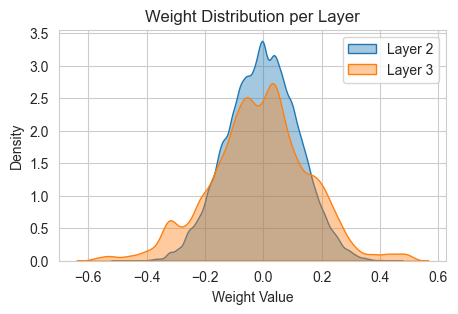

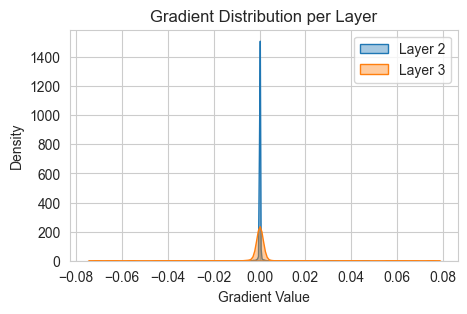

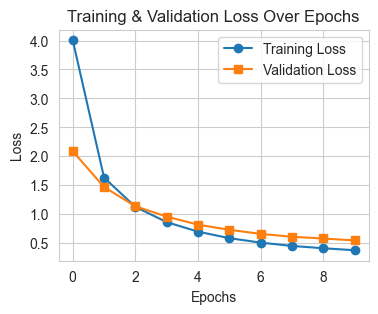

In [40]:
miawlenteraModel = FFNN([784,128,64,10], ['relu','relu','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

history = miawlenteraModel.fit(X_train, y_train, X_val, y_val, epochs=10, batch_size=64, lr=0.01, verbose=1)

lr_val_pred = miawlenteraModel.predict(X_val)
lr_test_pred = miawlenteraModel.predict(X_test)
y_val_labels = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(lr_val_pred, y_val_labels)
test_accuracy = accuracy_score(lr_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

miawlenteraModel.plot_distribution([0,1,2,3], plot_type="weight")
miawlenteraModel.plot_distribution([0,1,2,3], plot_type="gradient")
miawlenteraModel.plot_loss_history(history)

miawlenteraModel.save('./models/lr2.json')

Epoch 1/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 113974.49it/s]


Epoch 1 Completed - Train Loss: 10.1777 - Val Loss: 6.1109


Epoch 2/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 113859.13it/s]


Epoch 2 Completed - Train Loss: 5.1408 - Val Loss: 4.4624


Epoch 3/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 108581.46it/s]


...

Epoch 8 Completed - Train Loss: 2.3278 - Val Loss: 2.5061


Epoch 9/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 119848.32it/s]


Epoch 9 Completed - Train Loss: 2.1791 - Val Loss: 2.3723


Epoch 10/10: 100%|████████████████████████████████████████| 56000/56000 [00:00<00:00, 120877.79it/s]


Epoch 10 Completed - Train Loss: 2.0559 - Val Loss: 2.2716
Val accuracy: 85.29%, Test accuracy: 87.36%


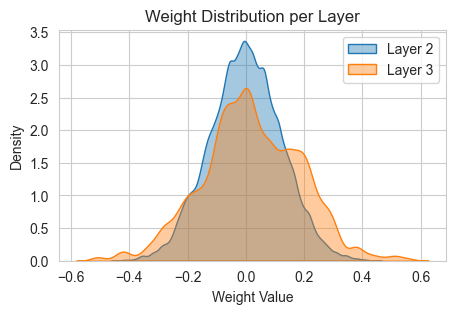

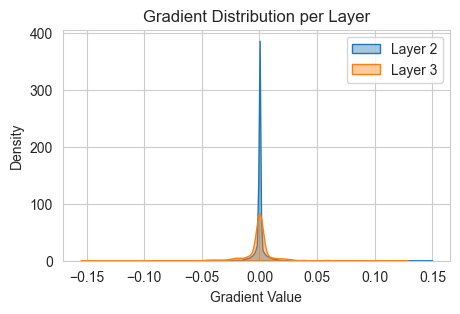

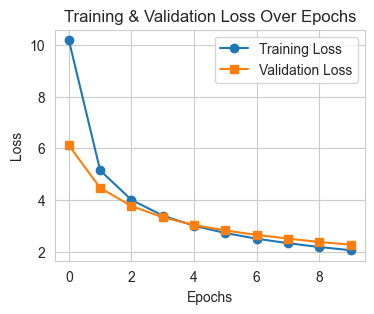

In [41]:
miawlenteraModel = FFNN([784,128,64,10], ['relu','relu','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

history = miawlenteraModel.fit(X_train, y_train, X_val, y_val, epochs=10, batch_size=64, lr=0.001, verbose=1)
lr_val_pred = miawlenteraModel.predict(X_val)
lr_test_pred = miawlenteraModel.predict(X_test)
y_val_labels = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(lr_val_pred, y_val_labels)
test_accuracy = accuracy_score(lr_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

miawlenteraModel.plot_distribution([0,1,2,3], plot_type="weight")
miawlenteraModel.plot_distribution([0,1,2,3], plot_type="gradient")
miawlenteraModel.plot_loss_history(history)

miawlenteraModel.save('./models/lr3.json')

As